# Домашнее задание по модулю «Ансамблирование моделей машинного обучения»

## Шаблон для выполнения

### 1. Анализ данных и базовые модели

1. Загрузите датасет `water_potability.csv`(возможно потребуется предварительно скачать его [по ссылке](https://www.kaggle.com/datasets/adityakadiwal/water-potability?resource=download)) и используйте столбец `Potability` как целевую переменную.

2. Проведите разведочный анализ данных:

   - Изучите распределение признаков и целевой переменной
   - Проверьте наличие пропущенных значений и дубликатов
   - Постройте визуализации для понимания структуры данных

3. Обучите и оцените базовые модели:

   - Дерево решений
   - Логистическая регрессия/линейная регрессия (в зависимости от типа задачи)
   - k-ближайших соседей

4. Для каждой модели рассчитайте метрики качества и сохраните результаты для последующего сравнения.

5. Проанализируйте результаты, уделяя особое внимание компромиссу между смещением и разбросом в каждой из моделей.

#### Анализ данных

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import time

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import StackingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
    )

from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
    )
from xgboost import XGBClassifier


In [ ]:
# загрузка датасета
df = pd.read_csv('water_potability.csv')
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


*Столбец Potability (пригодность воды для питья) - целевая переменная*

In [ ]:
# заполненность столбцов и типы данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


*Некоторые столбцы имеют пропуски. Все столбцы - числовые, что немного облегчит последующую предобработку.*

In [ ]:
# описательная статистика
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [ ]:
df.columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='object')

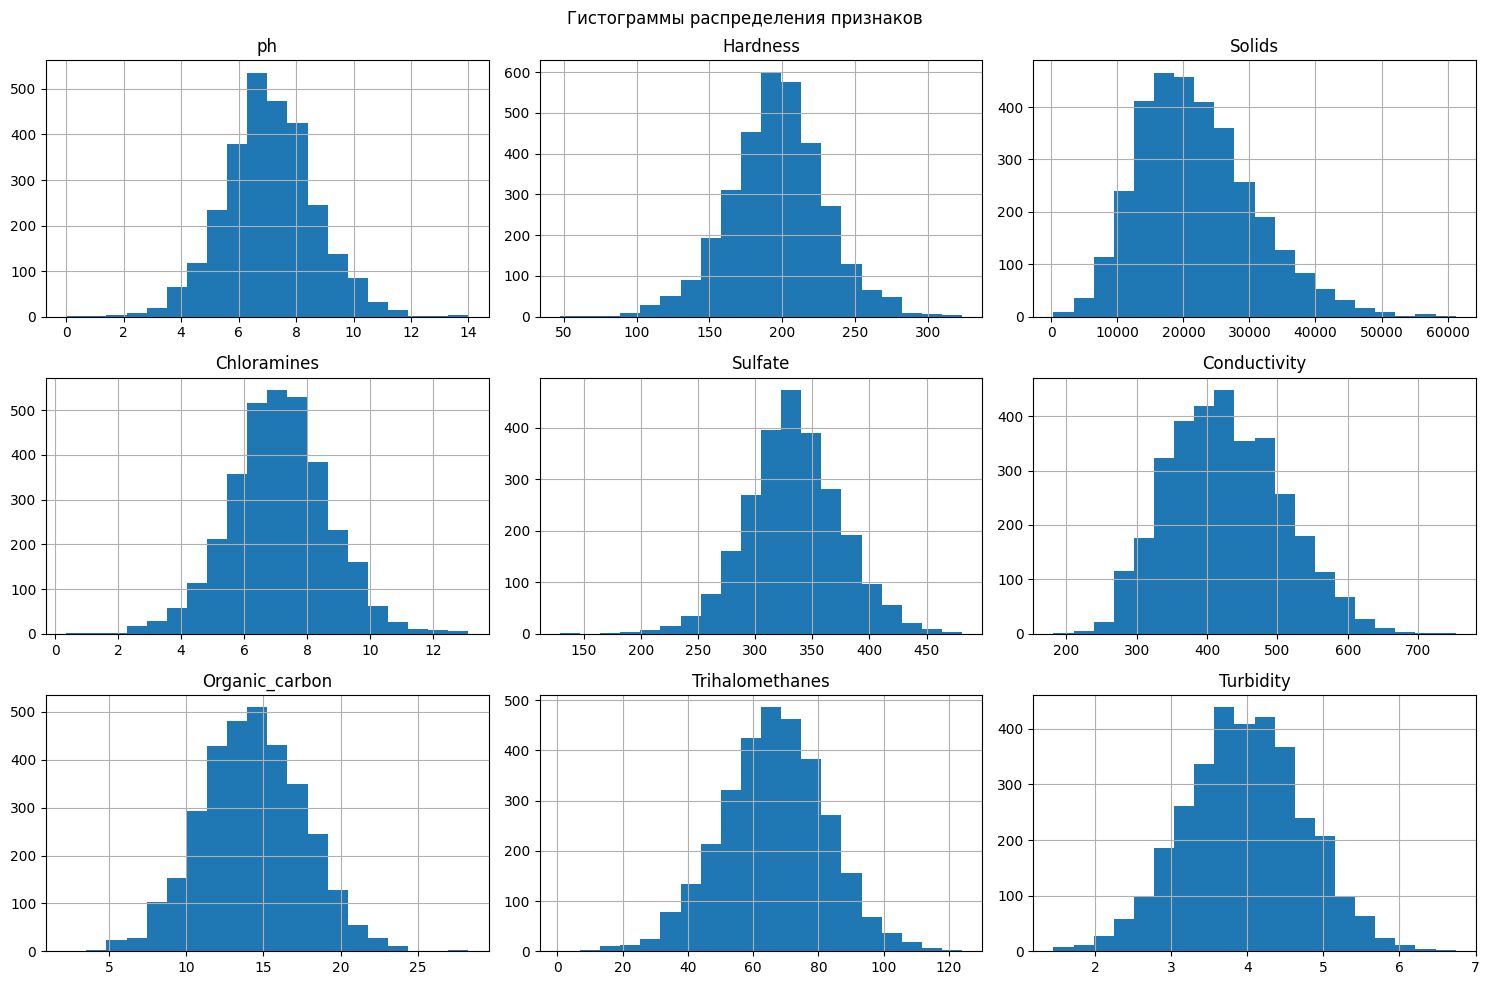

In [ ]:
# распределения признаков
df.drop(columns=['Potability']).hist(bins=20, figsize=(15,10), layout=(3,3))

plt.suptitle('Гистограммы распределения признаков')
plt.tight_layout()
plt.show()

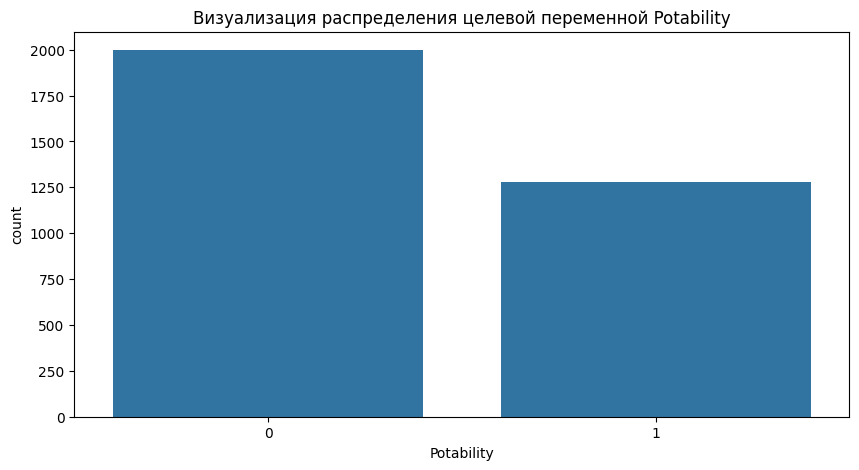

In [ ]:
# распределение целевой переменной
plt.figure(figsize=(10,5))

sns.countplot(x='Potability', data=df)

plt.title('Визуализация распределения целевой переменной Potability')
plt.show()

In [ ]:
# проверка баланса классов в целевой переменной
print(f'Количество значений {df['Potability'].value_counts().to_string()}\n')
print(f'Доля класса 0: {df['Potability'].value_counts(normalize=True)[0]:.2%}')
print(f'Доля класса 1: {df['Potability'].value_counts(normalize=True)[1]:.2%}')

Количество значений Potability
0    1998
1    1278

Доля класса 0: 60.99%
Доля класса 1: 39.01%


In [ ]:
# проверка на дубликаты
print(f'Количество дубликатов: {df.duplicated().sum()}\n')
df[df.duplicated()]

Количество дубликатов: 0



,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability


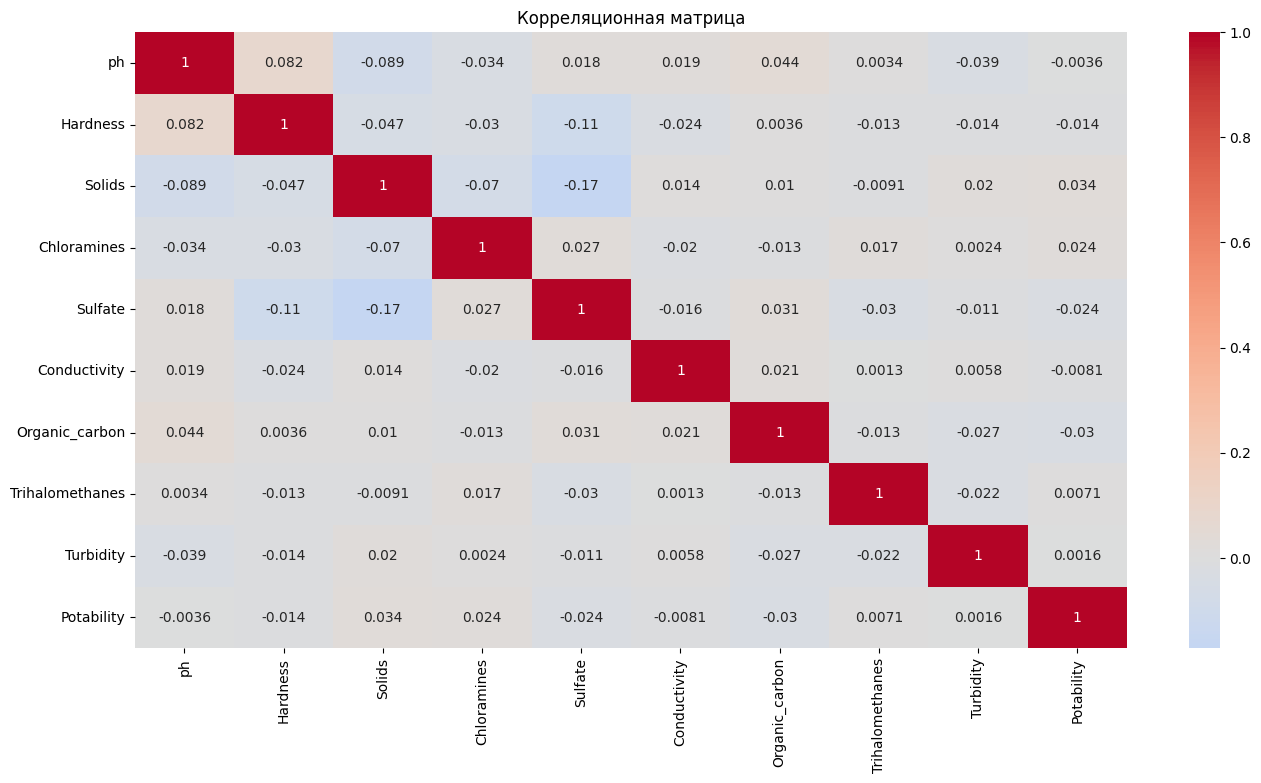

In [ ]:
# корреляционная матрица
corr_matrix = df.corr()

plt.figure(figsize=(16,8))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)

plt.title('Корреляционная матрица')
plt.show()

In [ ]:
# процентная доля пропусков в столбцах
print('Процентная доля пропусков в столбцах:')
df.isna().mean()*100

Процентная доля пропусков в столбцах:


,0
ph,14.987790
Hardness,0.000000
Solids,0.000000
Chloramines,0.000000
Sulfate,23.840049
Conductivity,0.000000
Organic_carbon,0.000000
Trihalomethanes,4.945055
Turbidity,0.000000
Potability,0.000000


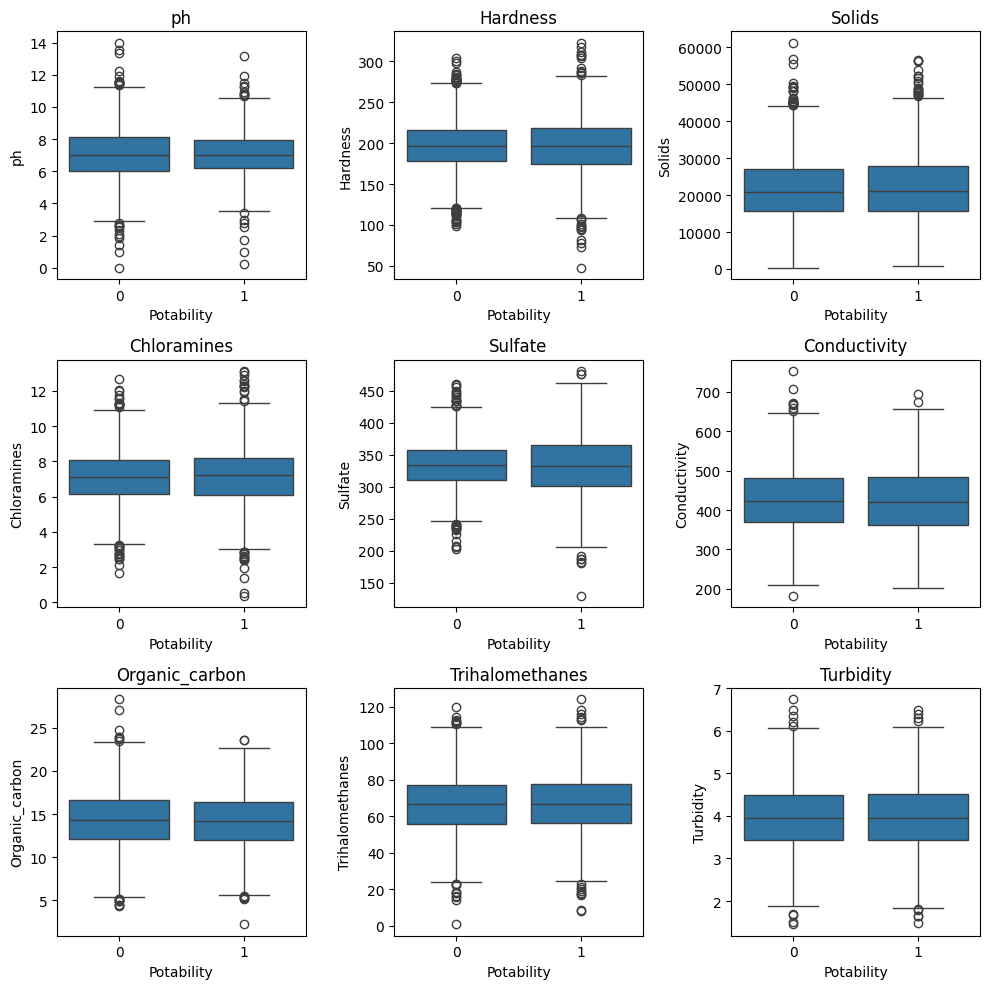

In [ ]:
# сравнение распределений признаков в зависимости от целевой переменной
features = df.drop(columns=['Potability']).columns

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=df, x='Potability', y=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

Выводы по EDA:
1. Большинство признаков имеют достаточно симметричное распределение, визуально близкое к нормальному.
2. По распределению целевой переменной наблюдается дисбаланс классов: класс 0 встречается чаще класса 1 примерно в 1,5 раза. Дисбаланс умеренный, поэтому решено оставить в таком виде.
3. В некоторых признаках (все из них числовые) присутствуют пропуски, они будут заполнены после `train/test` разделения на медиану `train` выборки для предотвращения утечки данных (в пайплайнах обучения моделей).
4. Значимых линейных корреляций между признаками, а также между отдельными признаками и целевой переменной не наблюдается.
5. Полные дубликаты отсутствуют.
6. Боксплоты показывают существенное перекрытие распределений признаков для классов `Potability = 0` и `Potability = 1`. То есть видно, что классы плохо разделяются отдельными признаками.

#### Обучение и оценка базовых моделей

In [ ]:
df_clean = df.copy()

In [ ]:
# определяем признаки и целевую переменную
X = df_clean.drop(columns=['Potability'])
y = df_clean['Potability']

In [ ]:
# разделение исходных данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
    )

*Объединим предобработку (заполнение пропусков и стандартизацию) и обучение в единые пайплайны. Для деревьев решений стандартизацию не включаем в пайплайн, т.к. она не требуется для этого метода. Для логистической регрессии стандартизация желательна (включаем), для SVM и kNN - обязательна.*

In [ ]:
# создаем пайплайны моделей для предобработки и обучения
# imputer заполняет пропуски согласно выбранной стратегии
# scaler стандартизует данные
dt_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42))
])

svm_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', SVC(probability=True, random_state=42))
])

knn_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier())
])

In [ ]:
# обучение моделей
dt_pipeline.fit(X_train, y_train)
lr_pipeline.fit(X_train, y_train)
svm_pipeline.fit(X_train, y_train)
knn_pipeline.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('classifier', KNeighborsClassifier())])

In [ ]:
# расчет предсказаний, метрик и таблица метрик обученных базовых моделей
models = {
    'DecisionTree': dt_pipeline,
    'LogisticRegression': lr_pipeline,
    'SVM': svm_pipeline,
    'KNeighborsClassifier': knn_pipeline
}

results = []

for name, model in models.items():
    # предсказания
    y_pred = model.predict(X_test)
    # вероятности положительного класса для roc-auc
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
    })

metrics_comparison_df = (
        pd.DataFrame(results)
        .set_index('Model')
        .T
        .round(4)
        )

metrics_comparison_df

Model,DecisionTree,LogisticRegression,SVM,KNeighborsClassifier
Accuracy,0.5960,0.6098,0.6707,0.6143
Precision,0.4813,0.0000,0.7041,0.5093
Recall,0.4531,0.0000,0.2695,0.3203
F1,0.4668,0.0000,0.3898,0.3933
ROC-AUC,0.5703,0.5481,0.6487,0.5978


In [ ]:
# сравнение качества моделей на train/test выборках для анализа смещения-дисперсии
for name, model in models.items():
    print(
        f'{name}: '
        f'Train Accuracy = {model.score(X_train, y_train):.4f},'
        f'Test Accuracy = {model.score(X_test, y_test):.4f}'
    )

DecisionTree: Train Accuracy = 1.0000,Test Accuracy = 0.5960
LogisticRegression: Train Accuracy = 0.6099,Test Accuracy = 0.6098
SVM: Train Accuracy = 0.7382,Test Accuracy = 0.6707
KNeighborsClassifier: Train Accuracy = 0.7641,Test Accuracy = 0.6143


**Вывод по результатам обучения базовых моделей.**

Низкие результаты базовых моделей подтверждают предварительные выводы по EDA: классы плохо разделяются отдельными признаками, выраженных линейных зависимостей с целевой переменной не наблюдается.

Анализ смещения-дисперсии показал различное поведение моделей.

* `DecisionTreeClassifier` ожидаемо демонстрирует сильное переобучение: `Train Accuracy = 1.0000` против `Test Accuracy = 0.5960`, то есть, имеем низкое смещение и высокую дисперсию.
* `LogisticRegression`, показывает практически низкое качество и на train, и на test (`Train Accuracy = 0.6099, Test Accuracy = 0.6098`), а также не обнаруживает объекты положительного класса, что указывает на высокое смещение и недостаточную сложность модели.
* `KNeighborsClassifier` тоже демонстрирует переобучение (`Train Accuracy = 0.7641,Test Accuracy = 0.6143`), однако оно значительно менее выражено, чем у дерева решений.
* Еще менее выраженное переобучение у `SVM` (`Train Accuracy = 0.7382,Test Accuracy = 0.6707`).

Среди обученных выше базовых моделей `SVM` показывает наибольшие `Accuracy = 0.6707` и `ROC-AUC = 0.6487` на тестовой выборке. Поэтому именно она выбирается в качестве базовой модели для последующего сравнения с ансамблевыми методами.

### 2. Реализация методов bagging и случайного леса

1. Обучите модель бэггинга (Bagging) на основе деревьев решений:

   - Проведите эксперименты с разным количеством базовых моделей (n_estimators от 10 до 100)
   - Исследуйте влияние параметров max_samples и max_features на качество модели

2. Обучите модель случайного леса (Random Forest):

   - Настройте гиперпараметры (n_estimators, max_depth, max_features) с помощью кросс-валидации
   - Сравните результаты с моделью бэггинга

3. Визуализируйте важность признаков для модели случайного леса.

* Постройте горизонтальный столбчатый график важности признаков
* Проанализируйте влияние признаков на пригодность воды для питья с точки зрения физико-химических свойств

4. Проведите сравнительный анализ:

   - Сравните качество базовых моделей, бэггинга и случайного леса
   - Проанализируйте, как ансамблирование влияет на смещение и разброс модели
   - Сделайте выводы о преимуществах случайного леса перед простым бэггингом для данной задачи

#### Реализация BaggingClassifier

In [ ]:
# схема кросс-валидации для бэггинга
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# метрики для оценки на кросс-валидации
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
    }

In [ ]:
# обучение модели бэггинга
# набор количеств базовых моделей
n_estimators_values = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

bagging_estimators_results = []

for n in n_estimators_values:
    bagging = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=n,
        bootstrap=True,
        random_state=42
        )
    # оценка модели только на обучающей выборке с помощью CV
    cv_results = cross_validate(
        bagging,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
        )
    # результаты в виде таблицы

    bagging_estimators_results.append({
        "Количество базовых моделей": n,
        "Train accuracy": cv_results['train_accuracy'].mean(),
        "CV accuracy": cv_results['test_accuracy'].mean(),
        "CV precision": cv_results['test_precision'].mean(),
        "CV recall": cv_results['test_recall'].mean(),
        "CV F1": cv_results['test_f1'].mean(),
        "CV ROC-AUC": cv_results['test_roc_auc'].mean()
        })

# результаты в виде таблицы
bagging_estimators_df = pd.DataFrame(bagging_estimators_results)
bagging_estimators_df.round(4)

,Количество базовых моделей,Train accuracy,CV accuracy,CV precision,CV recall,CV F1,CV ROC-AUC
0,10,0.9800,0.6458,0.5748,0.3542,0.4379,0.6458
1,20,0.9955,0.6599,0.6078,0.3601,0.4517,0.6750
2,30,0.9987,0.6607,0.6079,0.3699,0.4588,0.6750
3,40,0.9995,0.6660,0.6216,0.3669,0.4601,0.6788
4,50,0.9997,0.6668,0.6229,0.3659,0.4597,0.6766
5,60,1.0000,0.6691,0.6267,0.3718,0.4654,0.6833
6,70,1.0000,0.6710,0.6306,0.3757,0.4694,0.6851
7,80,1.0000,0.6679,0.6222,0.3728,0.4646,0.6857
8,90,1.0000,0.6721,0.6311,0.3816,0.4740,0.6884
9,100,1.0000,0.6748,0.6368,0.3845,0.4783,0.6898


In [ ]:
# автоматический выбор n_estimators по cv roc_auc
best_n_estimators = bagging_estimators_df.loc[
    bagging_estimators_df['CV ROC-AUC'].idxmax(),
    'Количество базовых моделей'
    ]
print(f'Лучшее n_estimators: {best_n_estimators}')

Лучшее n_estimators: 100


*По результатам 5-кратной кросс-валидации на обучающей выборке наибольший средний `ROC-AUC = 0.6898` получен при `n_estimators = 100`. Данное значение выбрано для дальнейшего исследования параметров `max_samples` и `max_features`. Тестовая выборка на этапе подбора гиперпараметров не использовалась.*

In [ ]:
# исследование влияния параметров max_samples и max_features на качество модели
max_samples_values = [0.5, 0.7, 0.9, 1.0]
max_features_values = [0.5, 0.7, 0.9, 1.0]

bagging_params_results = []

for samples in max_samples_values:
    for features in max_features_values:
        bagging = BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=42),
            n_estimators=best_n_estimators,
            bootstrap=True,
            max_samples=samples,
            max_features=features,
            random_state=42
            )

        # оценка параметров только на обучающей выборке с помощью CV
        cv_results = cross_validate(
            bagging,
            X_train,
            y_train,
            cv=cv,
            scoring=scoring,
            return_train_score=True,
            n_jobs=-1
            )

        bagging_params_results.append({
            "max_samples": samples,
            "max_features": features,
            "Train accuracy": cv_results['train_accuracy'].mean(),
            "CV accuracy": cv_results['test_accuracy'].mean(),
            "CV precision": cv_results['test_precision'].mean(),
            "CV recall": cv_results['test_recall'].mean(),
            "CV F1": cv_results['test_f1'].mean(),
            "CV ROC-AUC": cv_results['test_roc_auc'].mean()
            })

# результаты в виде таблицы
bagging_params_df = pd.DataFrame(bagging_params_results)
bagging_params_df.round(4)

,max_samples,max_features,Train accuracy,CV accuracy,CV precision,CV recall,CV F1,CV ROC-AUC
0,0.5,0.5,0.9945,0.6359,0.6212,0.1634,0.2569,0.6067
1,0.5,0.7,0.9902,0.6527,0.6410,0.2495,0.3572,0.6503
2,0.5,0.9,0.9820,0.6672,0.6429,0.3297,0.4348,0.6792
3,0.5,1.0,0.9789,0.6706,0.6383,0.3561,0.4559,0.6821
4,0.7,0.5,1.0000,0.6405,0.6390,0.1781,0.2781,0.6085
5,0.7,0.7,0.9999,0.6553,0.6357,0.2730,0.3812,0.6622
6,0.7,0.9,0.9991,0.6729,0.6474,0.3552,0.4582,0.6788
7,0.7,1.0,0.9983,0.6790,0.6478,0.3865,0.4836,0.6898
8,0.9,0.5,1.0000,0.6344,0.6094,0.1732,0.2682,0.6081
9,0.9,0.7,1.0000,0.6523,0.6244,0.2769,0.3815,0.6613


In [ ]:
# выбор лучших max_samples и max_features
best_bagging_params = bagging_params_df.loc[
    bagging_params_df['CV ROC-AUC'].idxmax()
    ]
best_max_samples = best_bagging_params['max_samples']
best_max_features = best_bagging_params['max_features']
print('Лучшие параметры Bagging:')
print(f'n_estimators = {best_n_estimators}')
print(f'max_samples = {best_max_samples}')
print(f'max_features = {best_max_features}')
print(f'CV ROC_AUC: {round(best_bagging_params['CV ROC-AUC'], 4)}')

Лучшие параметры Bagging:
n_estimators = 100
max_samples = 0.7
max_features = 1.0
CV ROC_AUC: 0.6898


*По результатам кросс-валидации лучшая конфигурация `Bagging` получена при `n_estimators = 100`, `max_samples = 0.7`, `max_features = 1.0`. Для неё средний `CV ROC-AUC = 0.6898`, что является максимальным значением среди рассмотренных комбинаций.*

*При увеличении `max_features` качество в целом растёт, тогда как слишком сильное уменьшение доли используемых объектов (`max_samples = 0.5`) несколько снижает результат. Лучшее качество достигается при использовании всех признаков и 70% объектов для обучения каждого базового дерева.*

*При этом `Train accuracy = 0.9983`, т.е. переобучение присутствует, однако выбор параметров выполнен корректно по кросс-валидации на обучающей выборке, без использования тестовой выборки.*

In [ ]:
# обучение лучшей модели Bagging на всей обучающей выборке
bagging_best = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=best_n_estimators,
    bootstrap=True,
    max_samples=best_max_samples,
    max_features=best_max_features,
    random_state=42
    )
bagging_best.fit(X_train, y_train)

# финальная оценка лучшего BaggingClassifier на тестовой выборке
y_pred_bagging = bagging_best.predict(X_test)
y_pred_bagging_train = bagging_best.predict(X_train)
y_pred_bagging_proba = bagging_best.predict_proba(X_test)[:, 1]

bagging_best_metrics = {
    'Train accuracy': accuracy_score(y_train, y_pred_bagging_train),
    'Test accuracy': accuracy_score(y_test, y_pred_bagging),
    'Precision': precision_score(y_test, y_pred_bagging, zero_division=0),
    'Recall': recall_score(y_test, y_pred_bagging),
    'F1': f1_score(y_test, y_pred_bagging),
    'ROC-AUC': roc_auc_score(y_test, y_pred_bagging_proba)
    }

In [ ]:
# сформируем датафрейм результатов лучшего BaggingClassifier
# для последующего сравнения c лучшим RandomForestClassifier
bagging_best_df = pd.DataFrame({
    'metrics': bagging_best_metrics.keys(),
    'Best BaggingClassifier': bagging_best_metrics.values()
    })

print('Метрики лучшей модели BaggingClassifier\n')
bagging_best_df.round(4)

Метрики лучшей модели BaggingClassifier



,metrics,Best BaggingClassifier
0,Train accuracy,0.9992
1,Test accuracy,0.6601
2,Precision,0.6241
3,Recall,0.3242
4,F1,0.4267
5,ROC-AUC,0.6503


#### Реализация RandomForestClassifier

In [ ]:
# подбор гиперпараметров RandomForestClassifier с помощью GridSearchCV
# пайплайн
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', RandomForestClassifier(random_state=42))
])

# сетка параметров
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 5, 10, 15],
    'classifier__max_features': ['sqrt', 0.5, 0.7, 1.0]
}

# подбор
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

# результаты подбора
print(f'Лучшие параметры: {grid_search.best_params_}')
print(f'Лучший CV ROC-AUC: {grid_search.best_score_:.4f}')

# готовая лучшая модель
rf_best = grid_search.best_estimator_

Лучшие параметры: {'classifier__max_depth': None, 'classifier__max_features': 0.7, 'classifier__n_estimators': 100}
Лучший CV ROC-AUC: 0.6916


*В качестве основной метрики для подбора гиперпараметров был выбран ROC-AUC, поскольку в целевой переменной наблюдается умеренный дисбаланс классов. При итоговом сравнении моделей дополнительно будут учитываться Accuracy, Precision, Recall и F1-score.*

In [ ]:
# метрики выбранной модели rf_best
y_pred_rf_best = rf_best.predict(X_test)
y_pred_rf_best_proba = rf_best.predict_proba(X_test)[:, 1]
y_pred_rf_best_train = rf_best.predict(X_train)

print('Метрики лучшей модели RandomForestClassifier\n')
rf_best_metrics_df = pd.DataFrame({
    'metrics' : [
        'Train accuracy',
        'Test accuracy',
        'Precision',
        'Recall',
        'F1',
        'ROC-AUC'
        ],
    'Best RandomForestClassifier' : [
        accuracy_score(y_train, y_pred_rf_best_train),
        accuracy_score(y_test, y_pred_rf_best),
        precision_score(y_test, y_pred_rf_best),
        recall_score(y_test, y_pred_rf_best),
        f1_score(y_test, y_pred_rf_best),
        roc_auc_score(y_test, y_pred_rf_best_proba)
        ]
})
rf_best_metrics_df.round(4)

Метрики лучшей модели RandomForestClassifier



,metrics,Best RandomForestClassifier
0,Train accuracy,1.0000
1,Test accuracy,0.6677
2,Precision,0.6418
3,Recall,0.3359
4,F1,0.4410
5,ROC-AUC,0.6517


In [ ]:
# сравнение результатов RandomForestClassifier и BaggingClassifier
ensemble_comparison_df = pd.merge(
    bagging_best_df,
    rf_best_metrics_df,
    on='metrics'
)


ensemble_comparison_df['diff'] = (
    ensemble_comparison_df['Best BaggingClassifier'] -
    ensemble_comparison_df['Best RandomForestClassifier']
    )

print('Сравнение метрик лучших моделей BaggingClassifier и RandomForestClassifier\n')
ensemble_comparison_df.round(4)

Сравнение метрик лучших моделей BaggingClassifier и RandomForestClassifier



,metrics,Best BaggingClassifier,Best RandomForestClassifier,diff
0,Train accuracy,0.9992,1.0000,-0.0008
1,Test accuracy,0.6601,0.6677,-0.0076
2,Precision,0.6241,0.6418,-0.0177
3,Recall,0.3242,0.3359,-0.0117
4,F1,0.4267,0.4410,-0.0143
5,ROC-AUC,0.6503,0.6517,-0.0014


***Сравнение Bagging и Random Forest.***

*`Random Forest` показал немного лучшие результаты, чем `Bagging`, по всем тестовым метрикам. `Test Accuracy` выше у `Random Forest` (0.6677 против 0.6601), так же как `Precision` (0.6418 против 0.6241), `Recall` (0.3359 против 0.3242) и `F1` (0.4410 против 0.4267). По `ROC-AUC` различие минимально: 0.6517 у `Random Forest` против 0.6503 у `Bagging`.*

*Обе модели сильно переобучаются по `Train Accuracy`, но `Random Forest` в данном эксперименте даёт немного более высокое и более сбалансированное качество на тестовой выборке.*

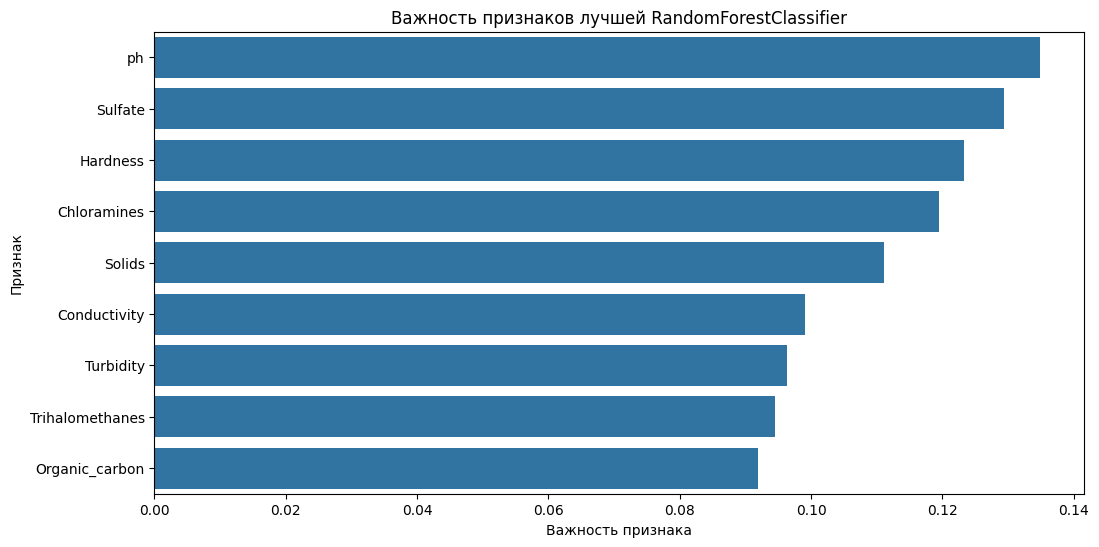

In [ ]:
# визуализация наиболее значимых признаков для модели случайного леса
plt.figure(figsize=(12,6))

importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_best.named_steps['classifier'].feature_importances_
    }).sort_values('importance', ascending=False)

sns.barplot(
    data=importances,
    x='importance',
    y='feature'
    )

plt.title('Важность признаков лучшей RandomForestClassifier')
plt.xlabel('Важность признака')
plt.ylabel('Признак')
plt.show()

***Анализ влияния признаков на пригодность воды.***

*Если говорить с точки зрения физико-химических свойств, то согласно полученным результатам наиболее сильное влияние на пригодность воды для питья в модели `RandomForest` оказывают кислотно-щелочной баланс воды, содержание сульфатов, жесткость, содержания хлораминов и общее количество растворенных твердых веществ (признаки `pH`, `Sulfate`, `Hardness`, `Chloramines` и `Solids` соответственно). При этом ни один показатель не является доминирующим, и значения важности признаков существенно друг от друга не отличаются. Это согласуется с результатами EDA, где не наблюдалось выраженного разделения классов по отдельным признакам. Следовательно, можно сделать вывод, что пригодность воды в рамках данного датасета определяется скорее совокупностью физико-химических характеристик, чем каким-либо отдельным показателем. В принципе, такое действительно и в реальных примерах.*

### 3. Реализация методов boosting

1. Обучите модель AdaBoost:

   - Настройте гиперпараметры (n_estimators, learning_rate) с помощью кросс-валидации
   - Проанализируйте, как модель последовательно исправляет ошибки предыдущих моделей
   - Визуализируйте изменение качества модели в зависимости от количества итераций

2. Обучите модель Gradient Boosting:

   - Настройте гиперпараметры (n_estimators, learning_rate, max_depth) с помощью кросс-валидации
   - Постройте графики зависимости качества от количества итераций

3. Обучите модель XGBoost:

   - Настройте ключевые гиперпараметры (eta, max_depth, subsample, colsample_bytree)
   - Сравните скорость обучения и качество с другими методами boosting

4. Проведите сравнительный анализ всех методов boosting:

   - Сравните качество, скорость обучения и стабильность моделей
   - Проанализируйте особенности каждого алгоритма и случаи их предпочтительного применения
   - Оцените влияние гиперпараметров на переобучение в каждом из методов

#### Реализация AdaBoostClassifier

In [ ]:
# подбор гиперпараметров AdaBoost с помощью GridSearchCV
# пайплайн
ada_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', AdaBoostClassifier(random_state=42))
])

# сетка параметров
ada_param_grid = {
    'classifier__n_estimators': [50, 100, 150, 200],
    'classifier__learning_rate': [0.01, 0.1, 0.5, 1.0]
    }

# подбор
ada_grid_search = GridSearchCV(
    estimator=ada_pipeline,
    param_grid=ada_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
ada_grid_search.fit(X_train, y_train)

# результаты подбора
print(f'Лучшие параметры: {ada_grid_search.best_params_}')
print(f'Лучший CV ROC-AUC: {ada_grid_search.best_score_:.4f}')

# готовая лучшая модель
ada_best = ada_grid_search.best_estimator_

Лучшие параметры: {'classifier__learning_rate': 0.5, 'classifier__n_estimators': 150}
Лучший CV ROC-AUC: 0.5597


In [ ]:
# метрики выбранной модели ada_best
y_pred_ada = ada_best.predict(X_test)
y_pred_ada_proba = ada_best.predict_proba(X_test)[:, 1]
y_pred_ada_train = ada_best.predict(X_train)

print('Метрики лучшей модели AdaBoostClassifier\n')
ada_best_metrics_df = pd.DataFrame({
    'metrics' : [
        'Train accuracy',
        'Test accuracy',
        'Precision',
        'Recall',
        'F1',
        'ROC-AUC'
        ],
    'Best AdaBoostClassifier' : [
        accuracy_score(y_train, y_pred_ada_train),
        accuracy_score(y_test, y_pred_ada),
        precision_score(y_test, y_pred_ada),
        recall_score(y_test, y_pred_ada),
        f1_score(y_test, y_pred_ada),
        roc_auc_score(y_test, y_pred_ada_proba)
        ]
})
ada_best_metrics_df.round(4)

Метрики лучшей модели AdaBoostClassifier



,metrics,Best AdaBoostClassifier
0,Train accuracy,0.6233
1,Test accuracy,0.6204
2,Precision,0.6842
3,Recall,0.0508
4,F1,0.0945
5,ROC-AUC,0.5808


In [ ]:
# извлечение обученных компонентов из пайплайна
ada_classifier = ada_best.named_steps['classifier']
ada_imputer = ada_best.named_steps['imputer']

# преобразование данных
X_train_ada = ada_imputer.transform(X_train)
X_test_ada = ada_imputer.transform(X_test)

# ROC-AUC после каждой итерации бустинга
ada_train_roc_auc = []
ada_test_roc_auc = []

for train_proba, test_proba in zip(
    ada_classifier.staged_predict_proba(X_train_ada),
    ada_classifier.staged_predict_proba(X_test_ada)
    ):
    ada_train_roc_auc.append(roc_auc_score(y_train, train_proba[:, 1]))
    ada_test_roc_auc.append(roc_auc_score(y_test, test_proba[:, 1]))

ada_stages_df = pd.DataFrame({
    'iteration': range(1, len(ada_train_roc_auc) + 1),
    'train_roc_auc': ada_train_roc_auc,
    'test_roc_auc': ada_test_roc_auc
})

ada_stages_df.round(4).head()

,iteration,train_roc_auc,test_roc_auc
0,1,0.5198,0.5179
1,2,0.5342,0.5274
2,3,0.5565,0.5384
3,4,0.5664,0.5499
4,5,0.5797,0.5460


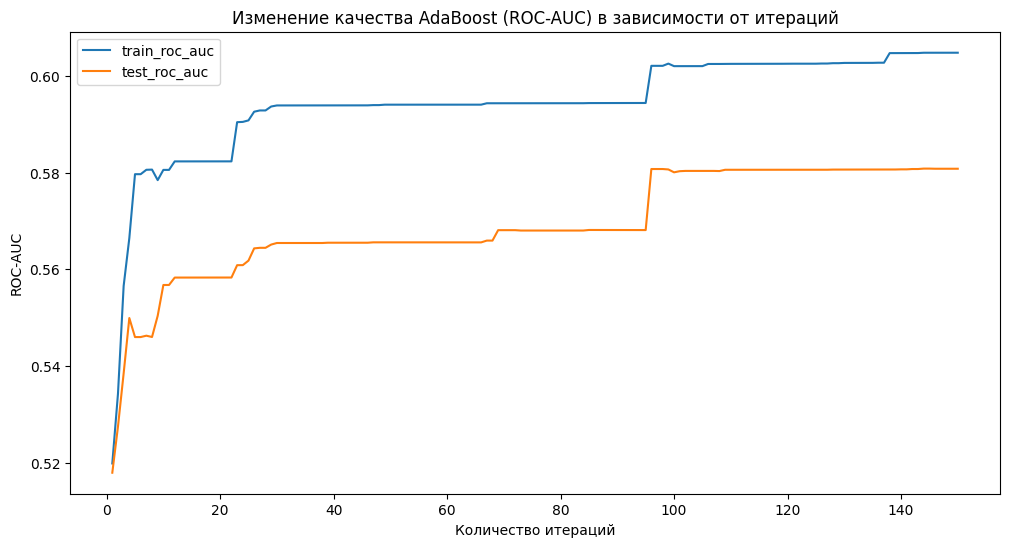

In [ ]:
# визуализация изменения качества модели в зависимости от количества итераций
plt.figure(figsize=(12,6))

sns.lineplot(
    data=ada_stages_df,
    x='iteration',
    y='train_roc_auc',
    label='train_roc_auc'
)

sns.lineplot(
    data=ada_stages_df,
    x='iteration',
    y='test_roc_auc',
    label='test_roc_auc'
)

plt.title('Изменение качества AdaBoost (ROC-AUC) в зависимости от итераций')
plt.xlabel('Количество итераций')
plt.ylabel('ROC-AUC')
plt.legend()
plt.show()

In [ ]:
# итерация с максимальным значением ROC-AUC на тестовой выборке
ada_best_iteration = ada_stages_df.loc[ada_stages_df['test_roc_auc'].idxmax()]
ada_best_iteration.round(4)

,143
iteration,144.0000
train_roc_auc,0.6048
test_roc_auc,0.5808


In [ ]:
# анализ последовательного исправления ошибок
ada_estimators_df = pd.DataFrame({
    'iteration': range(1, len(ada_classifier.estimator_errors_) + 1),
    'estimator_error': ada_classifier.estimator_errors_,
    'estimator_weight': ada_classifier.estimator_weights_
})

ada_estimators_df.round(4).head()

,iteration,estimator_error,estimator_weight
0,1,0.3771,0.2509
1,2,0.4306,0.1398
2,3,0.4560,0.0883
3,4,0.4882,0.0235
4,5,0.4645,0.0712


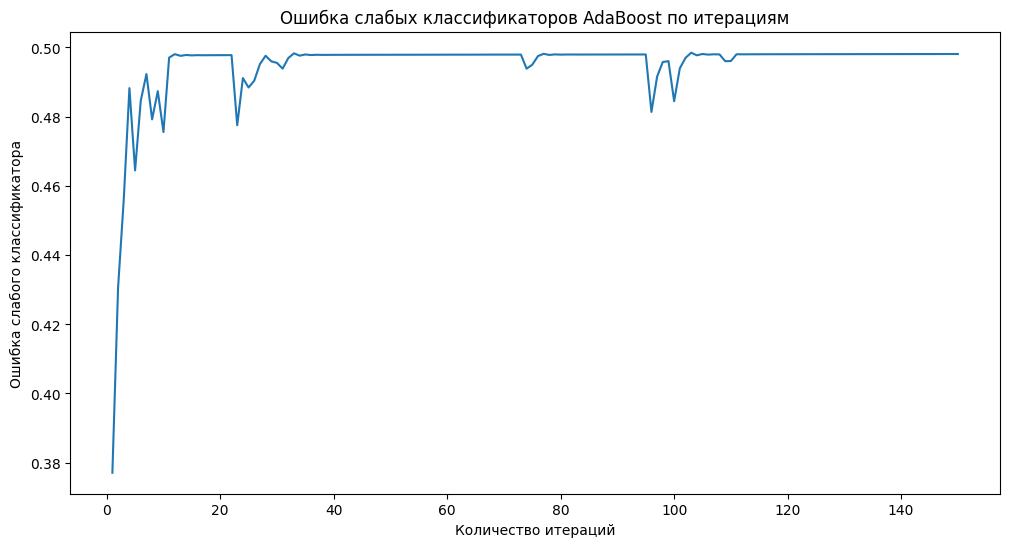

In [ ]:
# анализ последовательного исправления ошибок
plt.figure(figsize=(12,6))

sns.lineplot(
    data=ada_estimators_df,
    x='iteration',
    y='estimator_error'
)

plt.title('Ошибка слабых классификаторов AdaBoost по итерациям')
plt.xlabel('Количество итераций')
plt.ylabel('Ошибка слабого классификатора')
plt.show()

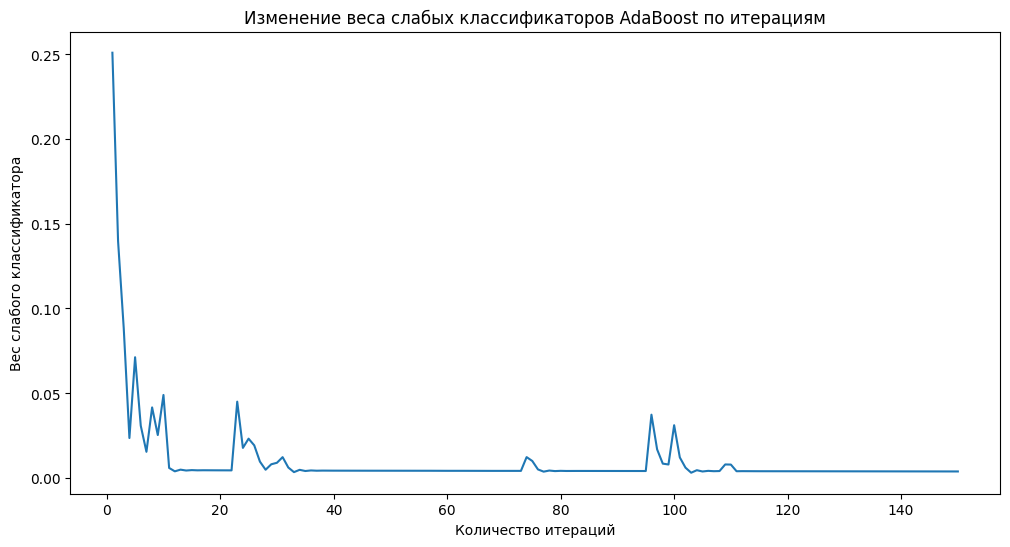

In [ ]:
# анализ последовательного исправления ошибок
plt.figure(figsize=(12,6))

sns.lineplot(
    data=ada_estimators_df,
    x='iteration',
    y='estimator_weight'
)

plt.title('Изменение веса слабых классификаторов AdaBoost по итерациям')
plt.xlabel('Количество итераций')
plt.ylabel('Вес слабого классификатора')
plt.show()

**Анализ работы AdaBoost по итерациям.**

На начальных итерациях добавление слабых классификаторов приводит к заметному росту ROC-AUC как на обучающей, так и на тестовой выборке. По мере увеличения числа итераций прирост качества замедляется, а после примерно 100 итераций Test ROC-AUC практически выходит на плато около 0.58. Максимальное значение `Test ROC-AUC = 0.5808` наблюдается на 144-й итерации и практически совпадает с результатом итоговой модели из 150 классификаторов.

Анализ ошибок и весов отдельных слабых классификаторов показывает механизм последовательного обучения `AdaBoost`. Первый классификатор имеет ошибку существенно ниже 0.5 и получает относительно большой вес. В дальнейшем ошибки большинства новых классификаторов приближаются к 0.5, поэтому их веса становятся очень небольшими. Отдельные снижения ошибки сопровождаются увеличением веса соответствующего классификатора и небольшими улучшениями качества ансамбля.

Таким образом, AdaBoost последовательно концентрируется на объектах, ошибочно классифицированных предыдущими моделями, однако для данного набора данных последующие слабые классификаторы быстро теряют способность эффективно исправлять оставшиеся ошибки. Это приводит к раннему замедлению роста качества и объясняет сравнительно низкий итоговый `ROC-AUC = 0.5808`.

#### Реализация GradientBoostingClassifier

In [ ]:
# подбор гиперпараметров GradientBoosting с помощью GridSearchCV
# пайплайн
gb_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

# сетка параметров
gb_param_grid = {
    'classifier__n_estimators': [50, 100, 150, 200],
    'classifier__learning_rate': [0.03, 0.05, 0.1, 0.2],
    'classifier__max_depth': [1, 2, 3, 5]
    }

# подбор
gb_grid_search = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
gb_grid_search.fit(X_train, y_train)

# результаты подбора
print(f'Лучшие параметры: {gb_grid_search.best_params_}')
print(f'Лучший CV ROC-AUC: {gb_grid_search.best_score_:.4f}')

# готовая лучшая модель
gb_best = gb_grid_search.best_estimator_

Лучшие параметры: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 5, 'classifier__n_estimators': 100}
Лучший CV ROC-AUC: 0.6521


In [ ]:
# метрики выбранной модели
y_pred_gb = gb_best.predict(X_test)
y_pred_gb_proba = gb_best.predict_proba(X_test)[:, 1]
y_pred_gb_train = gb_best.predict(X_train)

print('Метрики лучшей модели GradientBoostingClassifier\n')
gb_best_metrics_df = pd.DataFrame({
    'metrics' : [
        'Train accuracy',
        'Test accuracy',
        'Precision',
        'Recall',
        'F1',
        'ROC-AUC'
        ],
    'Best GradientBoostingClassifier' : [
        accuracy_score(y_train, y_pred_gb_train),
        accuracy_score(y_test, y_pred_gb),
        precision_score(y_test, y_pred_gb),
        recall_score(y_test, y_pred_gb),
        f1_score(y_test, y_pred_gb),
        roc_auc_score(y_test, y_pred_gb_proba)
        ]
})
gb_best_metrics_df.round(4)

Метрики лучшей модели GradientBoostingClassifier



,metrics,Best GradientBoostingClassifier
0,Train accuracy,0.7989
1,Test accuracy,0.6692
2,Precision,0.6822
3,Recall,0.2852
4,F1,0.4022
5,ROC-AUC,0.6691


In [ ]:
# извлечение обученных компонентов из пайплайна
gb_classifier = gb_best.named_steps['classifier']
gb_imputer = gb_best.named_steps['imputer']

# преобразование данных
X_train_gb = gb_imputer.transform(X_train)
X_test_gb = gb_imputer.transform(X_test)

# ROC-AUC после каждой итерации бустинга
gb_train_roc_auc = []
gb_test_roc_auc = []

for train_proba, test_proba in zip(
    gb_classifier.staged_predict_proba(X_train_gb),
    gb_classifier.staged_predict_proba(X_test_gb)
    ):
    gb_train_roc_auc.append(roc_auc_score(y_train, train_proba[:, 1]))
    gb_test_roc_auc.append(roc_auc_score(y_test, test_proba[:, 1]))

gb_stages_df = pd.DataFrame({
    'iteration': range(1, len(gb_train_roc_auc) + 1),
    'train_roc_auc': gb_train_roc_auc,
    'test_roc_auc': gb_test_roc_auc
})

gb_stages_df.round(4).head()

,iteration,train_roc_auc,test_roc_auc
0,1,0.6305,0.6043
1,2,0.6994,0.6186
2,3,0.7186,0.6304
3,4,0.7273,0.6419
4,5,0.7272,0.6397


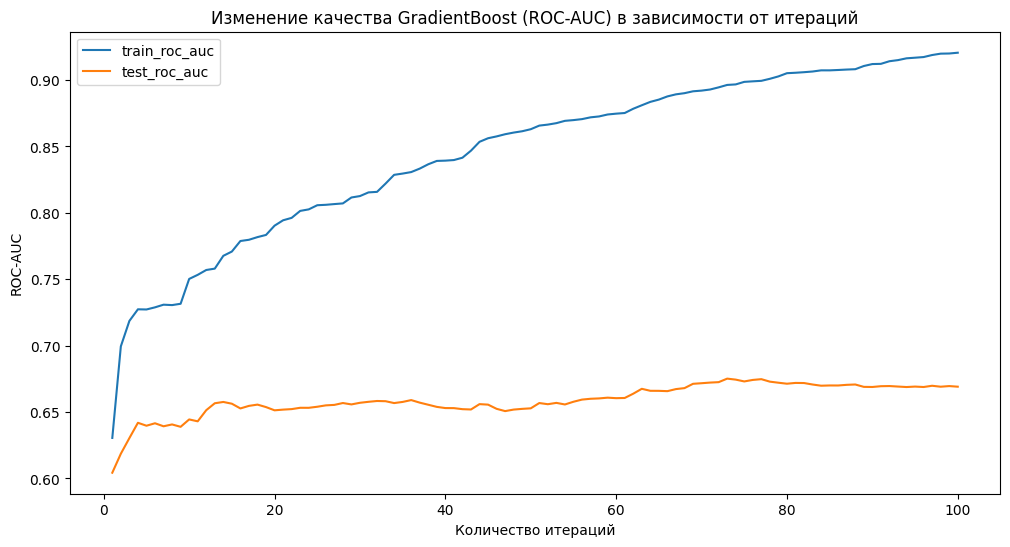

In [ ]:
# визуализация изменения качества модели в зависимости от количества итераций
plt.figure(figsize=(12,6))

sns.lineplot(
    data=gb_stages_df,
    x='iteration',
    y='train_roc_auc',
    label='train_roc_auc'
)

sns.lineplot(
    data=gb_stages_df,
    x='iteration',
    y='test_roc_auc',
    label='test_roc_auc'
)

plt.title('Изменение качества GradientBoost (ROC-AUC) в зависимости от итераций')
plt.xlabel('Количество итераций')
plt.ylabel('ROC-AUC')
plt.legend()
plt.show()

In [ ]:
# итерация с максимальным значением ROC-AUC на тестовой выборке
gb_best_iteration = gb_stages_df.loc[gb_stages_df['test_roc_auc'].idxmax()]
gb_best_iteration.round(4)

,72
iteration,73.0000
train_roc_auc,0.8963
test_roc_auc,0.6751


**Анализ Gradient Boosting по итерациям.**

На начальных итерациях добавление новых деревьев приводит к росту ROC-AUC как на обучающей, так и на тестовой выборке. Это отражает принцип работы градиентного бустинга: каждая следующая модель обучается на ошибках текущего ансамбля и последовательно улучшает его прогноз.

Максимальное значение `Test ROC-AUC = 0.6751` наблюдается на 73-й итерации. После этого качество на тестовой выборке перестаёт улучшаться и немного снижается, тогда как `Train ROC-AUC` продолжает расти и к концу обучения превышает 0.92. Увеличивающийся разрыв между train и test свидетельствует о переобучении модели при дальнейшем добавлении деревьев.

Таким образом, `Gradient Boosting` значительно лучше `AdaBoost` выявляет закономерности в данных, однако обладает более высокой дисперсией. После определённого числа итераций дальнейшее усложнение ансамбля улучшает качество на обучающей выборке, но уже не повышает обобщающую способность.

#### Реализация XGBClassifier

In [ ]:
# подбор гиперпараметров GradientBoosting с помощью GridSearchCV
# пайплайн
xgb_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', XGBClassifier(
        n_estimators=200,
        random_state=42,
        eval_metric='logloss'
        ))
])

# сетка параметров
xgb_param_grid = {
    'classifier__learning_rate': [0.03, 0.1, 0.2],
    'classifier__subsample': [0.7, 0.9, 1.0],
    'classifier__max_depth': [2, 3, 5],
    'classifier__colsample_bytree': [0.7, 0.9, 1.0]
    }

# подбор
xgb_grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
xgb_grid_search.fit(X_train, y_train)

# результаты подбора
print(f'Лучшие параметры: {xgb_grid_search.best_params_}')
print(f'Лучший CV ROC-AUC: {xgb_grid_search.best_score_:.4f}')

# готовая лучшая модель
xgb_best = xgb_grid_search.best_estimator_

Лучшие параметры: {'classifier__colsample_bytree': 0.9, 'classifier__learning_rate': 0.03, 'classifier__max_depth': 5, 'classifier__subsample': 0.7}
Лучший CV ROC-AUC: 0.6840


In [ ]:
# метрики выбранной модели
y_pred_xgb = xgb_best.predict(X_test)
y_pred_xgb_proba = xgb_best.predict_proba(X_test)[:, 1]
y_pred_xgb_train = xgb_best.predict(X_train)

print('Метрики лучшей модели XGBoostClassifier\n')
xgb_best_metrics_df = pd.DataFrame({
    'metrics' : [
        'Train accuracy',
        'Test accuracy',
        'Precision',
        'Recall',
        'F1',
        'ROC-AUC'
        ],
    'Best XGBoostClassifier' : [
        accuracy_score(y_train, y_pred_xgb_train),
        accuracy_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_xgb),
        roc_auc_score(y_test, y_pred_xgb_proba)
        ]
})
xgb_best_metrics_df.round(4)

Метрики лучшей модели XGBoostClassifier



,metrics,Best XGBoostClassifier
0,Train accuracy,0.8317
1,Test accuracy,0.6723
2,Precision,0.6667
3,Recall,0.3203
4,F1,0.4327
5,ROC-AUC,0.6742


In [ ]:
# извлечение обученных компонентов из пайплайна
xgb_classifier = xgb_best.named_steps['classifier']
xgb_imputer = xgb_best.named_steps['imputer']
n_estimators = xgb_classifier.n_estimators

# преобразование данных
X_train_xgb = xgb_imputer.transform(X_train)
X_test_xgb = xgb_imputer.transform(X_test)

# ROC-AUC после каждой итерации бустинга
xgb_train_roc_auc = []
xgb_test_roc_auc = []

for i in range(1, n_estimators + 1):
    train_proba = xgb_classifier.predict_proba(
        X_train_xgb,
        iteration_range=(0, i)
        )

    test_proba = xgb_classifier.predict_proba(
        X_test_xgb,
        iteration_range=(0, i)
        )

    xgb_train_roc_auc.append(roc_auc_score(y_train, train_proba[:, 1]))
    xgb_test_roc_auc.append(roc_auc_score(y_test, test_proba[:, 1]))

xgb_stages_df = pd.DataFrame({
    'iteration': range(1, len(xgb_train_roc_auc) + 1),
    'train_roc_auc': xgb_train_roc_auc,
    'test_roc_auc': xgb_test_roc_auc
})

xgb_stages_df.round(4).head()

,iteration,train_roc_auc,test_roc_auc
0,1,0.6415,0.5652
1,2,0.6584,0.5863
2,3,0.6665,0.5909
3,4,0.6761,0.5995
4,5,0.7230,0.6381


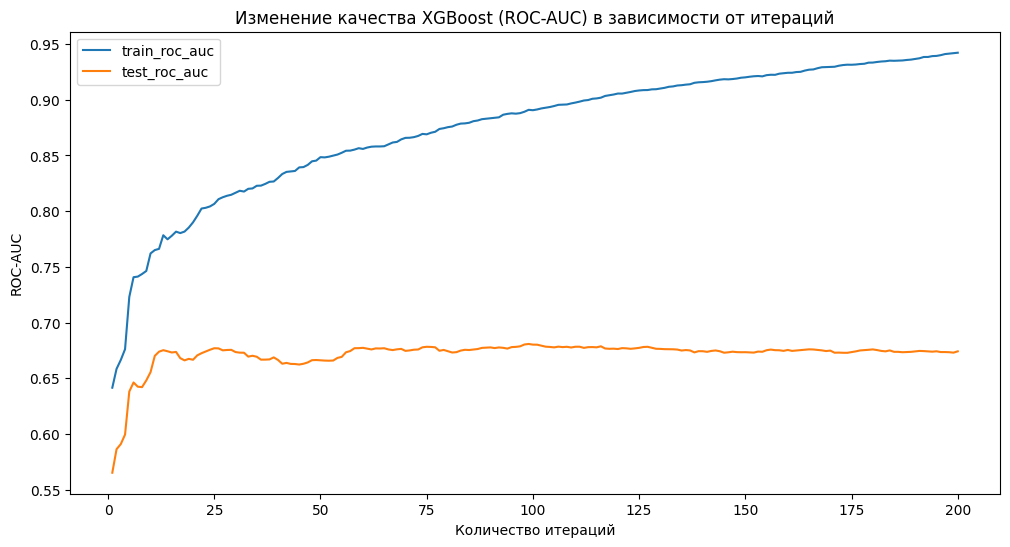

In [ ]:
# визуализация изменения качества модели в зависимости от количества итераций
plt.figure(figsize=(12,6))

sns.lineplot(
    data=xgb_stages_df,
    x='iteration',
    y='train_roc_auc',
    label='train_roc_auc'
)

sns.lineplot(
    data=xgb_stages_df,
    x='iteration',
    y='test_roc_auc',
    label='test_roc_auc'
)

plt.title('Изменение качества XGBoost (ROC-AUC) в зависимости от итераций')
plt.xlabel('Количество итераций')
plt.ylabel('ROC-AUC')
plt.legend()
plt.show()

In [ ]:
# итерация с максимальным значением ROC-AUC на тестовой выборке
xgb_best_iteration = xgb_stages_df.loc[xgb_stages_df['test_roc_auc'].idxmax()]
xgb_best_iteration.round(4)

,98
iteration,99.0000
train_roc_auc,0.8909
test_roc_auc,0.6808


**Анализ XGBoost.**

На тестовой выборке модель показала `Accuracy = 0.6723` и `ROC-AUC = 0.6742`. Разница между `Train Accuracy = 0.8317` и `Test Accuracy = 0.6723` указывает на наличие переобучения.

Анализ качества по итерациям показывает, что Test ROC-AUC быстро растёт на первых этапах обучения, а затем выходит на плато около 0.67–0.68. Максимальное значение `Test ROC-AUC = 0.6808` наблюдается на 99-й итерации. После этого Train ROC-AUC продолжает увеличиваться, тогда как качество на тестовой выборке практически не улучшается, что свидетельствует о дальнейшем росте переобучения.

В целом по метрикам `XGBoost` показывает существенно более высокое качество, чем `AdaBoost`, и результаты, близкие к `Gradient Boosting`. Использование `subsample < 1` и `colsample_bytree < 1` позволяет дополнительно ограничивать сложность ансамбля и уменьшать зависимость отдельных деревьев друг от друга.

#### Сравнительный анализ всех методов boosting

In [ ]:
# сравнение качества моделей бустинга
boosting_comparison_df = pd.DataFrame(
    ada_best_metrics_df
    .merge(gb_best_metrics_df, on='metrics')
    .merge(xgb_best_metrics_df, on='metrics')
)

print('Сравнение качества реализованных моделей бустинга\n')
boosting_comparison_df.round(4)

Сравнение качества реализованных моделей бустинга



,metrics,Best AdaBoostClassifier,Best GradientBoostingClassifier,Best XGBoostClassifier
0,Train accuracy,0.6233,0.7989,0.8317
1,Test accuracy,0.6204,0.6692,0.6723
2,Precision,0.6842,0.6822,0.6667
3,Recall,0.0508,0.2852,0.3203
4,F1,0.0945,0.4022,0.4327
5,ROC-AUC,0.5808,0.6691,0.6742


In [ ]:
# сравнение скорости обучения моделей бустинга
# клонируем модели с найденными гиперпараметрами для измерения времени обучения с нуля
boosting_models = {
    'AdaBoost': ada_best,
    'GradientBoost': gb_best,
    'XGBoost': xgb_best
}

training_times = []

for name, model in boosting_models.items():
    times = []

    for _ in range(5):
        model_clone = clone(model)

        start_time = time.perf_counter()
        model_clone.fit(X_train, y_train)
        end_time = time.perf_counter()

        times.append(end_time - start_time)

    training_times.append({
        'model': name,
        'mean training time': np.mean(times)
    })

boosting_time_df = pd.DataFrame(training_times)

print('Сравнение скорости обучения реализованных моделей бустинга (в сек)\n')
boosting_time_df.round(4)

Сравнение скорости обучения реализованных моделей бустинга (в сек)



,model,mean training time
0,AdaBoost,1.4898
1,GradientBoost,2.9864
2,XGBoost,0.3236


In [ ]:
# оценка моделей бустинга по CV для сравнения стабильности
boosting_stability_df = pd.DataFrame({
    'model': [
        'AdaBoost',
        'GradientBoost',
        'XGBoost'
        ],
    'Best CV ROC-AUC': [
        ada_grid_search.best_score_,
        gb_grid_search.best_score_,
        xgb_grid_search.best_score_
        ],
    'CV ROC_AUC std': [
        ada_grid_search.cv_results_['std_test_score'][ada_grid_search.best_index_],
        gb_grid_search.cv_results_['std_test_score'][gb_grid_search.best_index_],
        xgb_grid_search.cv_results_['std_test_score'][xgb_grid_search.best_index_]
        ]
})

print('Сравнение стабильности реализованных моделей бустинга (по std ROC-AUC лучшей конфигурации)\n')
boosting_stability_df.round(4)

Сравнение стабильности реализованных моделей бустинга (по std ROC-AUC лучшей конфигурации)



,model,Best CV ROC-AUC,CV ROC_AUC std
0,AdaBoost,0.5597,0.0040
1,GradientBoost,0.6521,0.0189
2,XGBoost,0.6840,0.0184


**Особенности алгоритмов**

* `AdaBoost` последовательно усиливает внимание к объектам, которые предыдущие слабые классификаторы классифицировали неправильно. В нашем случае новые слабые модели быстро стали давать ошибку, близкую к 0.5, их вклад в ансамбль уменьшался, и качество почти перестало расти. Поэтому `AdaBoost` здесь предпочтителен только как простой и устойчивый метод, но не как лучший по качеству.

* `Gradient Boosting` лучше выявляет сложные нелинейные зависимости, потому что каждое следующее дерево обучается в направлении уменьшения функции потерь. На этих данных он существенно превосходит `AdaBoost`, но сильнее склонен к переобучению: `Train ROC-AUC` продолжает расти после того, как `Test ROC-AUC` уже вышел на плато. Кроме того, он оказался самым медленным из трёх.

* `XGBoost` сочетает градиентный бустинг с дополнительными механизмами регуляризации и случайного отбора объектов и признаков. В нашей модели `subsample = 0.7` и `colsample_bytree = 0.9` помогают снизить зависимость отдельных деревьев друг от друга, а небольшой `learning_rate = 0.03` делает обучение более постепенным. Это дало лучший результат по качеству при одновременно самой высокой скорости.

**Влияние гиперпараметров на переобучение**

* Для `AdaBoost` основную роль играют `n_estimators` и `learning_rate`. Большой `learning_rate` усиливает влияние каждой новой модели, а большое число итераций увеличивает сложность ансамбля. В нашем случае при `n_estimators = 150` и `learning_rate = 0.5` сильного переобучения не возникло — скорее наблюдается высокое смещение.

* У `Gradient Boosting` переобучение сильнее зависит от комбинации `n_estimators`, `learning_rate` и `max_depth`. Более глубокие деревья и большое число итераций позволяют всё точнее подстраиваться под train. Это хорошо видно на графике: после определённого момента `Train ROC-AUC` продолжает расти, а `Test ROC-AUC` уже не улучшается.

* У `XGBoost` кроме `learning_rate` и `max_depth` есть дополнительные регуляторы `subsample` и `colsample_bytree`. Значения меньше 1.0 ограничивают использование объектов и признаков каждым деревом и тем самым снижают риск переобучения. Несмотря на это, после примерно 100 итераций у `XGBoost` тоже начинается рост разрыва между train и test.

**Сравнительный анализ методов бустинга.**

Среди исследованных методов наилучшее качество показал `XGBoostClassifier`: `Test Accuracy = 0.6723`, `F1 = 0.4327`, `ROC-AUC = 0.6742`. `GradientBoostingClassifier` показал близкий, но немного более низкий результат `(ROC-AUC = 0.6691`), тогда как `AdaBoost` существенно уступил остальным моделям (`ROC-AUC = 0.5808, F1 = 0.0945`).

По скорости обучения `XGBoost` также оказался наиболее эффективным, среднее время обучения моделей: `XGBoost = 0.32 с`, `AdaBoost = 1.49 с` и `Gradient Boosting = 2.99 с`.

С точки зрения стабильности наиболее низкий разброс ROC-AUC по фолдам показал `AdaBoost` (`std = 0.0040`), однако эта стабильность наблюдается при низком среднем качестве (`CV ROC-AUC = 0.5597`). `Gradient Boosting` и `XGBoost` имеют больший, но близкий разброс (`0.0189 и 0.0184` соответственно). При этом `XGBoost` сочетает более высокую стабильность, чем `Gradient Boosting`, с лучшим `CV ROC-AUC = 0.6840`.

`AdaBoost` в данной задаче характеризуется высоким смещением и слабой способностью распознавать положительный класс. `Gradient Boosting` лучше выявляет нелинейные зависимости, но сильнее склонен к переобучению и имеет наибольшее время обучения. `XGBoost` обеспечивает наиболее выгодный баланс между качеством, скоростью и устойчивостью за счёт небольшой скорости обучения (`learning_rate=0.03`) и дополнительных механизмов регуляризации через `subsample=0.7` и `colsample_bytree=0.9`.

***Таким образом, для данного набора данных наиболее предпочтительным методом бустинга является `XGBoost`.***

### 4. Реализация stacking и финальное сравнение моделей

1. Реализуйте метод stacking:

   - Используйте в качестве базовых моделей: дерево решений, случайный лес, градиентный бустинг
   - В качестве мета-модели используйте логистическую регрессию/линейную регрессию
   - Реализуйте двухуровневый стекинг с различными комбинациями моделей

2. Реализуйте метод blending:

   - Сравните результаты с методом stacking
   - Проанализируйте преимущества и недостатки каждого подхода

3. Проведите финальное сравнение всех моделей:

   - Сведите результаты всех моделей в единую таблицу
   - Постройте графики ROC-кривых или кривых обучения для визуального сравнения
   - Проанализируйте компромисс между сложностью модели и качеством предсказаний

4. Напишите общий вывод:

   - Какие методы ансамблирования показали наилучшие результаты для данного датасета?
   - Как гиперпараметры влияют на смещение и разброс в ансамблевых моделях?
   - Какие практические рекомендации можно дать по выбору метода ансамблирования для подобных задач?

#### Реализация Stacking

In [ ]:
# комбинации базовых моделей, мета-модель и пайплайны стекинга
stacking_combinations = {
    'DT + RF': [
        ('DecisionTree', DecisionTreeClassifier(random_state=42)),
        ('RandomForest', RandomForestClassifier(random_state=42))
    ],

    'DT + GB': [
        ('DecisionTree', DecisionTreeClassifier(random_state=42)),
        ('GradientBoosting', GradientBoostingClassifier(random_state=42))
    ],

    'RF + GB': [
        ('RandomForest', RandomForestClassifier(random_state=42)),
        ('GradientBoosting', GradientBoostingClassifier(random_state=42))
    ],

    'DT + RF + GB': [
        ('DecisionTree', DecisionTreeClassifier(random_state=42)),
        ('RandomForest', RandomForestClassifier(random_state=42)),
        ('GradientBoosting', GradientBoostingClassifier(random_state=42))
    ]
}

meta_model = LogisticRegression(random_state=42)

stacking_models = {}

for name, estimators in stacking_combinations.items():
    stacking_models[name] = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', StackingClassifier(
        estimators=estimators,
        final_estimator=meta_model,
        stack_method='predict_proba',
        cv=5,
        n_jobs=-1
        ))
    ])

In [ ]:
# обучение, расчет и сравнение метрик
stacking_results = []

for name, model in stacking_models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_pred_train = model.predict(X_train)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    stacking_results.append({
        'Model': name,
        'Train accuracy': accuracy_score(y_train, y_pred_train),
        'Test accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
        })

stacking_results_df = pd.DataFrame(stacking_results)

print('Сравнение метрик комбинаций моделей стекинга\n')
stacking_results_df.round(4)

Сравнение метрик комбинаций моделей стекинга



,Model,Train accuracy,Test accuracy,Precision,Recall,F1,ROC-AUC
0,DT + RF,1.0000,0.6616,0.6417,0.3008,0.4096,0.6418
1,DT + GB,0.7626,0.6494,0.6477,0.2227,0.3314,0.6371
2,RF + GB,1.0000,0.6662,0.6529,0.3086,0.4191,0.6438
3,DT + RF + GB,1.0000,0.6662,0.6555,0.3047,0.4160,0.6442


*По результатам реализации двухуровневого стекинга с комбинациями базовых моделей лучшие результаты по совокупности метрик показали комбинации `DecisionTree + RandomForest + GradientBoosting` и `RandomForest + GradientBoosting`. Их качество практически одинаково, при этом добавление `DecisionTree` к комбинации `RandomForest + GradientBoosting` не дало существенного прироста*

#### Реализация Blending

In [ ]:
# Разделение на train и validation
X_train_blend, X_valid, y_train_blend, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
    )

# обучение импьютера только на X_train_blend
blend_imputer = SimpleImputer(strategy='median')

# преобразование данных
X_train_blend_imp = blend_imputer.fit_transform(X_train_blend)
X_valid_imp = blend_imputer.transform(X_valid)
X_test_imp = blend_imputer.transform(X_test)

# применение тех же комбинаций моделей, что и в стекинге
blending_combinations = {
    'DT + RF': [
        ('DecisionTree', DecisionTreeClassifier(random_state=42)),
        ('RandomForest', RandomForestClassifier(random_state=42))
    ],

    'DT + GB': [
        ('DecisionTree', DecisionTreeClassifier(random_state=42)),
        ('GradientBoosting', GradientBoostingClassifier(random_state=42))
    ],

    'RF + GB': [
        ('RandomForest', RandomForestClassifier(random_state=42)),
        ('GradientBoosting', GradientBoostingClassifier(random_state=42))
    ],

    'DT + RF + GB': [
        ('DecisionTree', DecisionTreeClassifier(random_state=42)),
        ('RandomForest', RandomForestClassifier(random_state=42)),
        ('GradientBoosting', GradientBoostingClassifier(random_state=42))
    ]
}

In [ ]:
# непосредственно блэндинг
blending_results = []
blending_models = {}

for comb_name, estimators in blending_combinations.items():

    trained_estimators = []
    blend_predictions = []
    test_predictions = []

    # обучение базовых моделей
    for model_name, model in estimators:
        model.fit(X_train_blend_imp, y_train_blend)

        # вероятности для обучения мета-модели
        blend_proba = model.predict_proba(X_valid_imp)[:, 1]
        blend_predictions.append(blend_proba)

        # вероятности для теста
        test_proba = model.predict_proba(X_test_imp)[:, 1]
        test_predictions.append(test_proba)

        trained_estimators.append((model_name, model))

    # объединяем предсказания в метанабор
    X_meta_train = np.column_stack(blend_predictions)
    X_meta_test = np.column_stack(test_predictions)

    # мета-модель
    meta_model = LogisticRegression(random_state=42)
    meta_model.fit(X_meta_train, y_valid)

    # прогнозы
    y_pred_blend = meta_model.predict(X_meta_test)
    y_pred_blend_train = meta_model.predict(X_meta_train)
    y_pred_blend_proba = meta_model.predict_proba(X_meta_test)[:, 1]

    blending_results.append({
        'Model': comb_name,
        'Meta train accuracy': accuracy_score(y_valid, y_pred_blend_train),
        'Test accuracy': accuracy_score(y_test, y_pred_blend),
        'Precision': precision_score(y_test, y_pred_blend, zero_division=0),
        'Recall': recall_score(y_test, y_pred_blend),
        'F1': f1_score(y_test, y_pred_blend),
        'ROC-AUC': roc_auc_score(y_test, y_pred_blend_proba)
        })

    blending_models[comb_name] = {
        'base_models': trained_estimators,
        'meta_model': meta_model
        }

blending_results_df = pd.DataFrame(blending_results)

print('Сравнение метрик комбинаций моделей блендинга\n')
blending_results_df.round(4)

Сравнение метрик комбинаций моделей блендинга



,Model,Meta train accuracy,Test accuracy,Precision,Recall,F1,ROC-AUC
0,DT + RF,0.6794,0.6616,0.6466,0.2930,0.4032,0.6377
1,DT + GB,0.6469,0.6601,0.7143,0.2148,0.3303,0.6533
2,RF + GB,0.6775,0.6616,0.6545,0.2812,0.3934,0.6417
3,DT + RF + GB,0.6775,0.6555,0.6339,0.2773,0.3859,0.6433


*По результатам реализации блэндинга с теми же комбинациями базовых моделей, что и в стекинге, наиболее высокий `ROC-AUC` и `Precision` показала комбинация `DecisionTree + GradientBoosting`, тогда как `DecisionTree + RandomForest` имеет более сбалансированные значения `Recall` и `F1`. Однозначного лидера по всем метрикам среди комбинаций не наблюдается*

In [ ]:
# сравнение результатов стекинга и блэндинга
stack_new_columns = [stacking_results_df.columns[0]] + [
    'Accuracy_Stacking',
    'Precision_Stacking',
    'Recall_Stacking',
    'F1_Stacking',
    'ROC-AUC_Stacking'
    ]

blend_new_columns = [blending_results_df.columns[0]] + [
    'Accuracy_Blending',
    'Precision_Blending',
    'Recall_Blending',
    'F1_Blending',
    'ROC-AUC_Blending'
    ]

stacking_results_df = stacking_results_df.drop(columns='Train accuracy')
blending_results_df = blending_results_df.drop(columns='Meta train accuracy')

stacking_results_df.columns = stack_new_columns
blending_results_df.columns = blend_new_columns

blend_stack_comparison_df = pd.DataFrame(
    stacking_results_df
    .merge(blending_results_df, on='Model')
    )

columns_order = [
    'Model',
    'Accuracy_Stacking',
    'Accuracy_Blending',
    'Precision_Stacking',
    'Precision_Blending',
    'Recall_Stacking',
    'Recall_Blending',
    'F1_Stacking',
    'F1_Blending',
    'ROC-AUC_Stacking',
    'ROC-AUC_Blending'
]

blend_stack_comparison_df = blend_stack_comparison_df[columns_order]

print('Сравнение метрик стекинга и блендинга\n')
blend_stack_comparison_df.round(4)

Сравнение метрик стекинга и блендинга



,Model,Accuracy_Stacking,Accuracy_Blending,Precision_Stacking,Precision_Blending,Recall_Stacking,Recall_Blending,F1_Stacking,F1_Blending,ROC-AUC_Stacking,ROC-AUC_Blending
0,DT + RF,0.6616,0.6616,0.6417,0.6466,0.3008,0.2930,0.4096,0.4032,0.6418,0.6377
1,DT + GB,0.6494,0.6601,0.6477,0.7143,0.2227,0.2148,0.3314,0.3303,0.6371,0.6533
2,RF + GB,0.6662,0.6616,0.6529,0.6545,0.3086,0.2812,0.4191,0.3934,0.6438,0.6417
3,DT + RF + GB,0.6662,0.6555,0.6555,0.6339,0.3047,0.2773,0.4160,0.3859,0.6442,0.6433


**Сравнение Stacking и Blending.**

В большинстве исследованных комбинаций `Stacking` показывает немного более высокие `Recall`, `F1` и `ROC-AUC`, особенно для `RF + GB` и `DT + RF + GB`. `Blending` уступил не сильно, а для комбинации `DT + GB` даже превзошёл `Stacking` по `Accuracy`, `Precision` и `ROC-AUC`. Таким образом, однозначного и существенного преимущества одного подхода для всех комбинаций нет, однако в данной задаче `Stacking` в целом даёт более сбалансированный результат.

Основное преимущество `Stacking` — более эффективное использование обучающих данных за счёт out-of-fold прогнозов, что особенно важно при сравнительно небольшом объёме выборки. Это и проявилось в данной задаче с небольшим датасетом (`shape = (3276, 10)`). Его недостатки — более высокая вычислительная сложность и время обучения. `Blending` проще и быстрее, но требует выделения отдельной validation-части, из-за чего базовые модели обучаются не на всех доступных данных, а итоговый результат сильнее зависит от конкретного разбиения.

#### Финальное сравнение всех моделей

Итоговый набор моделей для сравнения:

1. SVM
2. Bagging
3. RandomForest
4. AdaBoost
5. GradientBoosting
6. XGBoost
7. лучший Stacking
8. лучший Blending

Необходимо извлечь из существующих результатов по одной строке на итоговую модель и привести их к единому виду.

In [ ]:
# У Bagging, Random Forest и всех трёх бустингов одинаковая структура
# определение функции для них
def get_model_metrics(df, value_column, model_name):
    """Возвращает основные метрики классификации для модели.
    Parameters
    ----------
    df : pandas.DataFrame
        Датафрейм с названиями метрик в столбце 'metrics'.
    value_column : str
        Название столбца со значениями метрик.
    model_name : str
        Название модели для итоговой сравнительной таблицы.

    Returns
    -------
    dict
        Словарь с названием модели и основными тестовыми метриками.
    """
    metrics = df.set_index('metrics')[value_column]

    return {
        'Model': model_name,
        'Accuracy': metrics['Test accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1': metrics['F1'],
        'ROC-AUC': metrics['ROC-AUC']
    }

In [ ]:
# формирование списка финальных моделей
# svm
svm_metrics = next(
    result for result in results
    if result['Model'] == 'SVM'
    )

# остальные модели
final_results = [
    svm_metrics,

    get_model_metrics(
        bagging_best_df,
        'Best BaggingClassifier',
        'BaggingClassifier'
        ),
    get_model_metrics(
        rf_best_metrics_df,
        'Best RandomForestClassifier',
        'RandomForestClassifier'
        ),
    get_model_metrics(
        ada_best_metrics_df,
        'Best AdaBoostClassifier',
        'AdaBoostClassifier'
        ),
    get_model_metrics(
        gb_best_metrics_df,
        'Best GradientBoostingClassifier',
        'GradientBoostingClassifier'
        ),
    get_model_metrics(
        xgb_best_metrics_df,
        'Best XGBoostClassifier',
        'XGBoostClassifier'
        )
    ]

# лучшие по ROC-AUC комбинации в Stacking и Blending
best_stacking = stacking_results_df.loc[
    stacking_results_df['ROC-AUC_Stacking'].idxmax()
    ]
best_blending = blending_results_df.loc[
    blending_results_df['ROC-AUC_Blending'].idxmax()
    ]

final_results.append({
    'Model': f'Stacking ({best_stacking['Model']})',
    'Accuracy': best_stacking['Accuracy_Stacking'],
    'Precision': best_stacking['Precision_Stacking'],
    'Recall': best_stacking['Recall_Stacking'],
    'F1': best_stacking['F1_Stacking'],
    'ROC-AUC': best_stacking['ROC-AUC_Stacking']
    })
final_results.append({
    'Model': f'Blending ({best_blending['Model']})',
    'Accuracy': best_blending['Accuracy_Blending'],
    'Precision': best_blending['Precision_Blending'],
    'Recall': best_blending['Recall_Blending'],
    'F1': best_blending['F1_Blending'],
    'ROC-AUC': best_blending['ROC-AUC_Blending']
    })

In [ ]:
# итоговая таблица сравнения качества моделей
final_models_comparison_df = pd.DataFrame(final_results)

print('Итоговая таблица сравнения качества моделей\n')
final_models_comparison_df.round(4)

Итоговая таблица сравнения качества моделей



,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,SVM,0.6707,0.7041,0.2695,0.3898,0.6487
1,BaggingClassifier,0.6601,0.6241,0.3242,0.4267,0.6503
2,RandomForestClassifier,0.6677,0.6418,0.3359,0.4410,0.6517
3,AdaBoostClassifier,0.6204,0.6842,0.0508,0.0945,0.5808
4,GradientBoostingClassifier,0.6692,0.6822,0.2852,0.4022,0.6691
5,XGBoostClassifier,0.6723,0.6667,0.3203,0.4327,0.6742
6,Stacking (DT + RF + GB),0.6662,0.6555,0.3047,0.4160,0.6442
7,Blending (DT + GB),0.6601,0.7143,0.2148,0.3303,0.6533


Для визуализации кривых соберем вероятности положительного класса

In [ ]:
# вероятности положительного класса для основных моделей
roc_probas = {
    'SVM': svm_pipeline.predict_proba(X_test)[:, 1],
    'BaggingClassifier': bagging_best.predict_proba(X_test)[:, 1],
    'RandomForestClassifier': rf_best.predict_proba(X_test)[:, 1],
    'AdaBoostClassifier': ada_best.predict_proba(X_test)[:, 1],
    'GradientBoostingClassifier': gb_best.predict_proba(X_test)[:, 1],
    'XGBoostClassifier': xgb_best.predict_proba(X_test)[:, 1]
    }

# определение лучшей комбинации стекинга по ROC-AUC
best_stacking_name = stacking_results_df.loc[
    stacking_results_df['ROC-AUC_Stacking'].idxmax(), 'Model'
    ]

# получение обученной модели лучшего стекинга
best_stacking_model = stacking_models[best_stacking_name]

# добавление вероятностей лучшего стекинга в общий словарь
roc_probas[f'Stacking ({best_stacking_name})'] = (
    best_stacking_model.predict_proba(X_test)[:, 1]
    )

# определение лучшей комбинации блендинга по ROC-AUC
best_blending_name = blending_results_df.loc[
    blending_results_df['ROC-AUC_Blending'].idxmax(), 'Model'
    ]

# получение сохраненных базовых и мета-модели лучшего блендинга
best_blending_model = blending_models[best_blending_name]

# получение вероятностей базовых моделей блендинга на тестовой выборке
blend_test_predictions = []

for model_name, model in best_blending_model['base_models']:
    model_proba = model.predict_proba(X_test_imp)[:, 1]
    blend_test_predictions.append(model_proba)

# формирование метапризнаков для тестовой выборки
X_meta_test_best = np.column_stack(blend_test_predictions)

# получение итоговых вероятностей положительного класса от мета-модели блендинга
best_blending_proba = (
    best_blending_model['meta_model']
    .predict_proba(X_meta_test_best)[:, 1]
)

# добавление вероятностей лучшего блендинга в общий словарь
roc_probas[f'Blending ({best_blending_name})'] = best_blending_proba

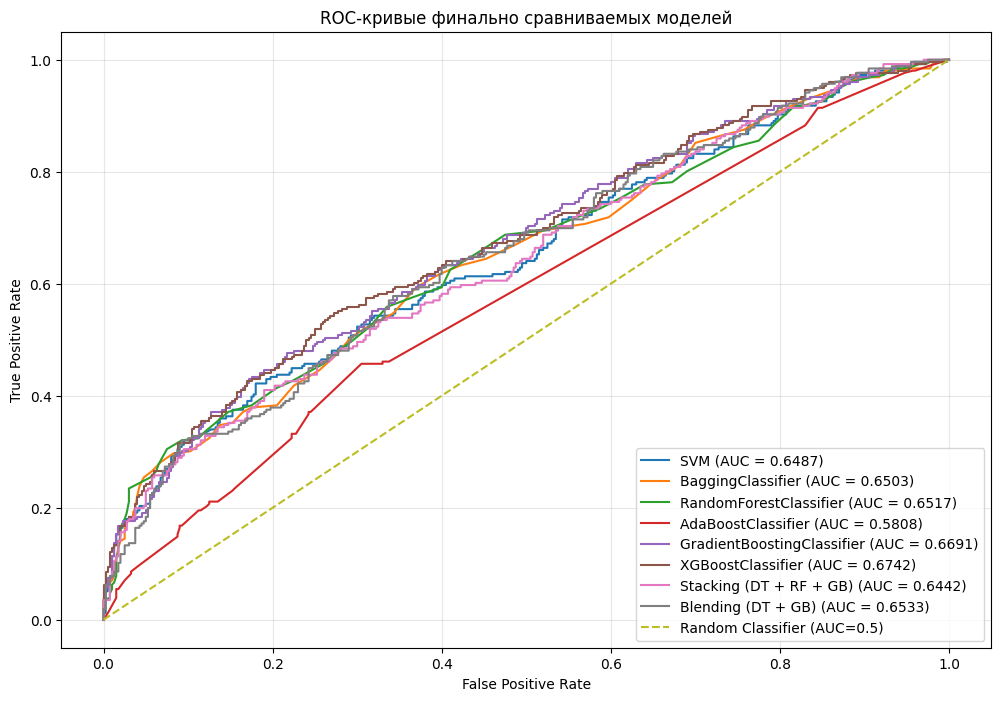

In [ ]:
# визуализация ROC-кривых
plt.figure(figsize=(12,8))

for name, y_proba in roc_probas.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

# линия случайного классификатора
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier (AUC=0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые финально сравниваемых моделей')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

**Финальное сравнение качества моделей**

Лучшее общее качество показал `XGBoostClassifier`: `Accuracy = 0.6723`, `ROC-AUC = 0.6742`. Очень близок `GradientBoostingClassifier` (`Accuracy = 0.6692`, `ROC-AUC = 0.6691`). `RandomForestClassifier` немного уступает по `ROC-AUC = 0.6517`, но имеет лучшие `Recall = 0.3359` и `F1 = 0.4410`, то есть лучше выявляет положительный класс при выбранном пороге.

`SVM` оказался сильной базовой моделью: `Accuracy = 0.6707`, `Precision = 0.7041`, `ROC-AUC = 0.6487`. По Accuracy SVM практически не уступает лучшим ансамблям, однако по `Recall = 0.2695` и `F1 = 0.3898` он слабее `Random Forest` и `XGBoost`. `Stacking` (`ROC-AUC = 0.6442`) и `blending` (`ROC-AUC = 0.6533`) не превзошли лучшие отдельные ансамбли, а `AdaBoost` показал худший результат по `Recall = 0.0508`.

Визуальный анализ ROC-кривых подтверждает, что `XGBoost` и `Gradient Boosting` лучше остальных отделяют классы, а `SVM` и `Random Forest` показывают близкое, но немного более слабое качество. При этом даже у лучших моделей ROC-AUC находится около 0.67, поэтому в данной задаче можно говорить об умеренном качестве классификации. Это согласуется с проведённым ранее EDA: классы сильно перекрываются по отдельным признакам, и задача классификации сама по себе достаточно сложная.

**Компромисс между сложностью и качеством**

Сравнение показало, что более сложные ансамблевые модели дают некоторое улучшение качества, но прирост относительно лучшей базовой `SVM` уже не очень большой. `SVM` как базовая модель имеет `ROC-AUC = 0.6487`, тогда как лучшие ансамбли достигают примерно `0.67`.

Наиболее удачный баланс дают `Random Forest`, `Gradient Boosting` и `XGBoost`. `XGBoost` сложнее по настройке, но показал лучшее итоговое качество; `Random Forest` дал лучшие `Recall` и `F1`. При этом `SVM` оказался достаточно конкурентоспособным при более простой архитектуре и показал высокие `Accuracy` и `Precision`.

`Stacking` и `blending` ещё сложнее в реализации, но дополнительного прироста качества в данной задаче не дали, поэтому их усложнение здесь не дало заметного результата.

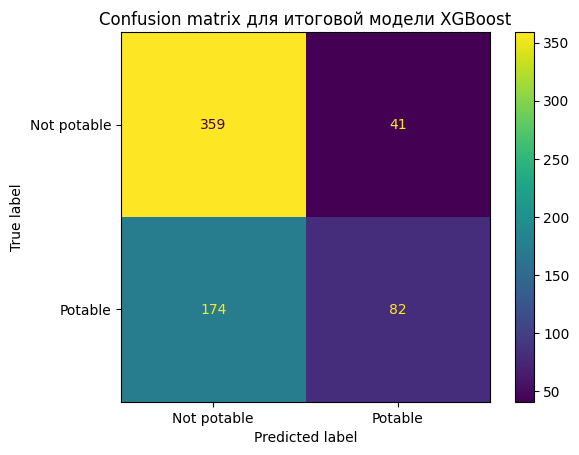

In [ ]:
# матрица ошибок для лучшей по качеству модели - XGBoost
# предсказания итоговой модели на тестовой выборке
y_pred_xgb_final = xgb_best.predict(X_test)

# построение матрицы ошибок
cm = confusion_matrix(y_test, y_pred_xgb_final)

# визуализация матрицы ошибок
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not potable', 'Potable']
)

disp.plot()
plt.title('Confusion matrix для итоговой модели XGBoost')
plt.show()

In [ ]:
# извлечение количества ошибок и правильных классификаций
tn, fp, fn, tp = cm.ravel()

print('True Negative:', tn)
print('False Positive:', fp)
print('False Negative:', fn)
print('True Positive:', tp)

True Negative: 359
False Positive: 41
False Negative: 174
True Positive: 82


Матрица ошибок показывает, что `XGBoost` значительно лучше распознаёт класс `Not potable`, чем `Potable`. Модель правильно классифицировала 359 непригодных образцов (TN) и только 82 пригодных (TP). При этом допущено 41 ложноположительная ошибка (FP) и 174 ложноотрицательные (FN).

Основная проблема модели — большое число `False Negative`: из 256 реально пригодных образцов правильно найдено только 82, что соответствует `Recall` около 0.32. То есть модель часто относит пригодную воду к непригодной. Ложноположительных ошибок существенно меньше: модель сравнительно редко признаёт непригодную воду пригодной.

Таким образом, итоговая модель лучше распознаёт отрицательный класс и работает достаточно консервативно по отношению к классу `Potable`.

## Выводы

Напишите здесь свои выводы по результатам работы:

1. Какие методы ансамблирования показали наилучшие результаты для прогнозирования качества воды?

По итогам экспериментов в данной задаче лучшие результаты показали `XGBoost`, `Gradient Boosting` и `Random Forest`.

Наилучшее общее качество получил `XGBoostClassifier`: `Accuracy = 0.6723`, `ROC-AUC = 0.6742`. Очень близкий результат показал `GradientBoostingClassifier` с `Accuracy = 0.6692` и `ROC-AUC = 0.6691`. При этом `Random Forest` немного уступая по `ROC-AUC`, оказался лучшим по `Recall = 0.3359` и `F1 = 0.4410`, то есть лучше других моделей находил объекты положительного класса.

Поэтому для этой задачи наиболее удачным методом можно считать `XGBoost`.

2. Как гиперпараметры влияют на смещение и разброс в ансамблевых моделях?

Гиперпараметры напрямую влияют на сложность ансамбля и, соответственно, на баланс между смещением и дисперсией.

В `Bagging` и `Random Forest` увеличение числа деревьев обычно делает результат стабильнее, но слишком сложные базовые деревья могут всё равно переобучаться. Ограничение глубины дерева, уменьшение `max_samples` или `max_features` снижает дисперсию, но при слишком сильных ограничениях может увеличиться смещение и ухудшиться качество.

В бустинге важную роль играют `n_estimators`, `learning_rate` и `max_depth`. Увеличение числа и глубины деревьев уменьшает смещение, но повышает риск переобучения. Более низкий `learning_rate` делает обучение более постепенным и обычно требует большего числа деревьев. В `XGBoost` параметры `subsample` и `colsample_bytree` дополнительно ограничивают модель и помогают уменьшать дисперсию. В экспериментах, проведенных в данной задаче было видно, что у `Gradient Boosting` и `XGBoost` после определённого количества итераций качество на `train` продолжало расти, а на `test` переставало улучшаться, что является признаком роста дисперсии.

3. Какие практические рекомендации можно дать по выбору метода ансамблирования для подобных задач?

Для подобных задач с табличными числовыми данными в первую очередь можно рассматривать `Random Forest`,` Gradient Boosting` и `XGBoost`, а затем сравнивать их по кросс-валидации и нескольким метрикам, а не только по `Accuracy`.

Если нужен более простой и понятный вариант, хорошим выбором может быть `Bagging` или `Random Forest`. Если основная цель — получить максимальное качество и есть возможность более тщательно настраивать гиперпараметры, имеет смысл использовать `Gradient Boosting` или `XGBoost`.

`Stacking` и `blending` стоит применять, когда базовые модели действительно дают достаточно разные ошибки и их комбинация улучшает результат. В данной задаче усложнение за счёт `stacking` и `blending` не привело к улучшению качества относительно `XGBoost` и `Gradient Boosting`, поэтому использовать их здесь только ради большей сложности нецелесообразно.

В целом для этой задачи наиболее рациональным и оптимальным выбором выглядит `XGBoost` как модель с лучшим общим качеством.